# 強度の導入

In [ ]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside jepx-data-analytics.")
PROJECT_DIR = (
    REPO_ROOT
    / "A_Hawkes_Model_Approach_to_Modeling_Price_Spikes_in_the_Japanese_Electricity_Market"
)
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import sys
from pathlib import Path

# projectルートを追加
sys.path.append(str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)

numpy: 1.26.4
pandas: 2.3.3
matplotlib: 3.9.4


In [ ]:
import pandas as pd

spike_long = pd.read_csv(
    (PROJECT_DATA_DIR / "processed/spike_long.csv"), parse_dates=["date"]
)

spike_long.head()

,index,date,area,time_code,price,u,x
0,0,2016-04-01,Chubu,1,6.69,0,0.0
1,1,2016-04-01,Chubu,2,6.34,0,0.0
2,2,2016-04-01,Chubu,3,6.34,0,0.0
3,3,2016-04-01,Chubu,4,6.03,0,0.0
4,4,2016-04-01,Chubu,5,6.57,0,0.0


In [ ]:
u_tokyo = pd.read_csv(
    (PROJECT_DATA_DIR / "processed/u_dict/u_Tokyo.csv"), index_col=0, parse_dates=True
)

u_tokyo.head()

,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
date,,,,,,,,,,,,,,,,,,,,,
2016-04-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-04-02,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-04-03,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-04-04,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-04-05,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
x_tokyo = pd.read_csv(
    (PROJECT_DATA_DIR / "processed/x_dict/x_Tokyo.csv"), index_col=0, parse_dates=True
)

x_tokyo.head()

,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
date,,,,,,,,,,,,,,,,,,,,,
2016-04-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-04-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-04-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-04-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-04-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


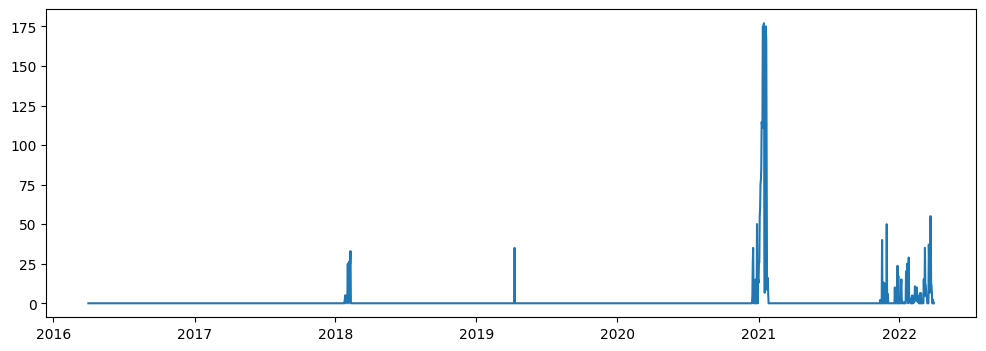

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(x_tokyo["15"])
plt.show()

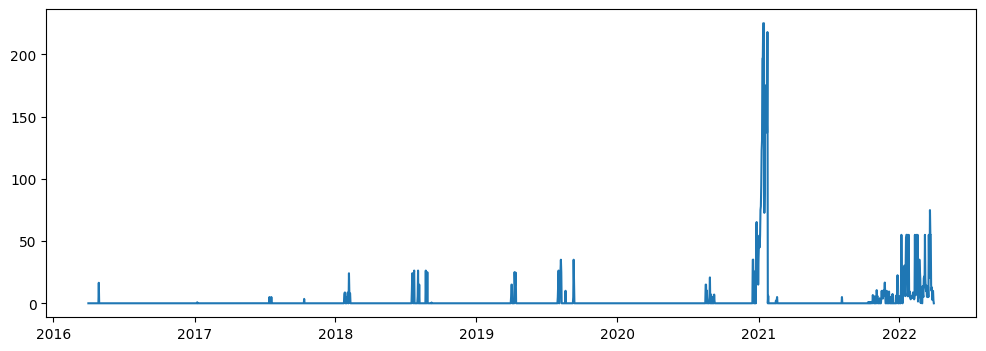

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(x_tokyo["37"])
plt.show()

## モデル
観測前強度$\lambda_d^-$と観測後強度$\lambda_d^+$を区別し、$\alpha , \beta , \gamma$を逐次ベイズ推定することが目標。

### Hawkes I

$$
\lambda_d^- = \alpha \lambda_{d-1}^+ + \beta,\qquad \lambda_d^+=\lambda_d^-+\gamma u_d
$$

$$
\alpha = \exp{\left(-\frac{1}{\tau}\right)}\ , \ \beta = \mu(1- \alpha)
$$

$$
\gamma : \text{スパイクが来た時のジャンプ量}
$$

### Hawkes II
強いショックは強い連鎖を生む

$$
\lambda_d = \alpha \lambda_{d-1} + \beta + \gamma_d u_d
$$

$$
\gamma_d = \gamma_0 (1 - \exp{\left( -\frac{x_d}{x_0}\right)})
$$

### Hawkes III
強いショックは長く尾を引く

$$
\lambda_d = \alpha_d \lambda_{d-1} + \beta + \gamma u_d
$$

$$
\tau_d = \tau_0 (1 - \exp{\left( -\frac{x_d}{x_0}\right)})
$$

In [7]:
def compute_lambda(u, alpha, beta, gamma):
    # u_dの尤度に使う観測前強度だけを返す（当日のu_dを先に混ぜない）
    lambda_pred = []
    lam_plus = beta / (1 - alpha)
    for ud in u:
        lam_minus = alpha * lam_plus + beta
        lambda_pred.append(lam_minus)
        lam_plus = lam_minus + gamma * ud
    return np.asarray(lambda_pred)

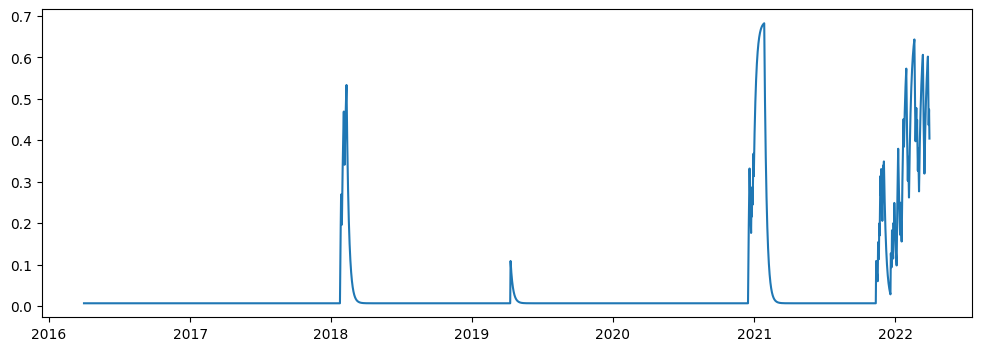

In [ ]:
plt.figure(figsize=(12, 4))
u = u_tokyo["15"].values
lambda_tokyo_15 = compute_lambda(u, alpha=0.85, beta=0.001, gamma=0.12)
plt.plot(u_tokyo["15"].index, lambda_tokyo_15)